In [44]:
import math
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torchvision import datasets, models, transforms
from torchvision.datasets import ImageFolder

from PIL import Image

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

#####
import h5py
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import typing as t
import cv2
from torchvision.transforms import (
    Compose,
    Grayscale,
    Resize,
    ToTensor,
)
from typing_extensions import Literal

In [45]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device is : {device}")


Device is : cuda:0


In [3]:
!gpu run nvidia-smi

Wed Jun 22 17:21:50 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 510.60.02    Driver Version: 510.60.02    CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:03:00.0 Off |                  N/A |
| 30%   31C    P8    21W / 350W |      2MiB / 24576MiB |      0%   E. Process |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:82:00.0 Off |                  N/A |
| 30%   

In [46]:
import os
import random

# seed for reproducibility

def set_random_seed(random_seed=None):
    """
    Using random seed for numpy and torch
    """
    if(random_seed is None):
        random_seed = 13
    os.environ['PYTHONHASHSEED'] = str(random_seed)
    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    return


set_random_seed()


### Data Preparation and Exploration

In [47]:
def get_simple_2d_transforms() -> t.Callable[
    [t.Union[Image.Image, np.ndarray]], torch.Tensor
]:
    return Compose([Resize(64), Grayscale(), ToTensor()])

def process_single_2d_image(
    image: np.ndarray,
    transforms: t.Optional[
        t.Callable[[np.ndarray], t.Union[torch.Tensor, np.ndarray]]
    ],
) -> t.Tuple[torch.Tensor, ...]:
    height, width = image.shape[0], image.shape[1]
    current_max_distance = max(width, height) * math.sqrt(2)

    thresholded = (cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) > 0).astype(
        np.uint8
    )
    distances = cv2.distanceTransform(1 - thresholded, cv2.DIST_L2, maskSize=0)
    coords = np.stack(
        np.meshgrid(range(width), range(height)), axis=-1
    ).reshape(
        (-1, 2)
    )  # -> N, (x, y)
    distances = distances[coords[:, 1], coords[:, 0]]

    y_indices, x_indices = np.where(thresholded == 1)
    y_min, y_max = y_indices.min(), y_indices.max()
    x_min, x_max = x_indices.min(), x_indices.max()

    bounding_h = (y_max - y_min) / current_max_distance
    bounding_w = (x_max - x_min) / current_max_distance

    bounding_volume = bounding_h * bounding_w

    dim = max(height, width)

    coords = coords.astype(np.float32)
    coords = (coords + 0.5) / dim - 0.5

    if transforms is not None:
        image = Image.fromarray(image, mode="RGB")
        image = transforms(image)
    else:
        image = torch.from_numpy(image).float() / 255
    coords = torch.from_numpy(coords).float()

    distances = (distances <= 0).astype(np.float32)
    return image, coords, distances, bounding_volume

In [48]:
class CADDataset(Dataset):
    def __init__(
        self,
        h5_file_path: str,
        data_split: Literal["train", "valid", "test"],
        transforms: t.Optional[t.Callable[[np.ndarray], torch.Tensor]] = None,
    ):

        super().__init__()

        self.h5_file_path = h5_file_path
        self.transforms = transforms
        self.data_split = data_split

        if data_split == "train":
            self.data_key = "train_images"
        elif data_split == "valid":
            self.data_key = "val_images"
        else:
            self.data_key = "test_images"

        with h5py.File(self.h5_file_path, "r") as h5_file:
            self._images = h5_file[self.data_key][:]

        self.__cache = {}

    def __len__(self) -> int:
        return len(self._images)

    def __getitem__(self, index: int) -> t.Tuple[torch.Tensor, ...]:
        if index in self.__cache:
            return self.__cache[index]
        image = self._images[index].astype(np.uint8) * 255
        image = np.expand_dims(image, axis=-1).repeat(3, axis=-1)
        image, coords, distances, bounding_volume = process_single_2d_image(
            image, self.transforms
        )

        self.__cache[index] = (image, coords, distances, bounding_volume)

        return image, coords, distances, bounding_volume

In [50]:
def dataloader(
        training: bool, split_type: Literal["train", "valid"]
    ) -> DataLoader:
        data_path = './cad.h5'
        batch_size = 16
        transforms = get_simple_2d_transforms()
        loader = DataLoader(
            dataset=CADDataset(data_path, split_type, transforms),
            batch_size=batch_size,
            shuffle=training,
            drop_last=training,
            num_workers=0,
        )
        return loader

def train_dataloader() -> DataLoader:
    return dataloader(True, "train")

def val_dataloader() -> DataLoader:
    return dataloader(False, "valid")

In [51]:
batch_size = 16

train_loader = train_dataloader()
valid_loader = val_dataloader()


In [52]:
s = next(iter(train_loader))
s[0].shape, s[1].shape, s[2].shape, s[3].shape

(torch.Size([16, 1, 64, 64]),
 torch.Size([16, 4096, 2]),
 torch.Size([16, 4096]),
 torch.Size([16]))

In [ ]:
from torchvision.utils import make_grid


def show_grid(data, titles=None):
    """Imshow for Tensor."""
    data = data.numpy().transpose((0, 2, 3, 1))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    data = std * data + mean
    data = np.clip(data, 0, 1)

    plt.figure(figsize=(8*2, 4*2))
    for i in range(32):
        plt.subplot(4, 8, i+1)
        plt.imshow(data[i])
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

# Get a batch of training data and displaying it
inputs= next(iter(train_loader))


show_grid(inputs)


# Modeling

In [53]:
def get_act(act_name):
    """ Gettign activation given name """
    assert act_name in ["ReLU", "Sigmoid", "Tanh"]
    activation = getattr(nn, act_name)
    return activation()
    
def get_dropout(drop_p):
    """ Getting a dropout layer """
    if(drop_p):
        drop = nn.Dropout(p=drop_p)
    else:
        drop = nn.Identity()
    return drop

class Reshape(nn.Module):
    """ Module for reshaping a tensor"""
    def __init__(self, size):
        """ Module initializer"""
        super().__init__()
        self.size = size
        
    def forward(self,x):
        """ Rehaping channel spatial dimension"""
        y = x.view(-1, *self.size)
        return y

In [54]:
class VanillaAE(nn.Module):
    """
    Implementation of a fully connect autoencoder for 
    denoising  MNIST images
    """
    
    def __init__(self, in_size=(1,64,64), sizes=[1024, 128, 10], act="ReLU", dropout_in=0.2, dropout_hid=0.5):
        """ Model initlaizer """
        assert np.prod(in_size) == sizes[0]
        super().__init__()
        
        self.in_size = in_size
        self.sizes = sizes
        self.activation = get_act(act) 
        self.drop_in = get_dropout(dropout_in)
        self.drop_hid = get_dropout(dropout_hid)
        
        self.encoder = self._make_encoder()
        self.decoder = self._make_decoder()
        return
        
    def _make_encoder(self):
        """ Defining encoder """
        layers = [nn.Flatten()]
        
        # adding fc+act+drop for each layer
        for i in range(len(self.sizes)-1):
            layers.append( nn.Linear(in_features=self.sizes[i], out_features=self.sizes[i+1]) )
            layers.append(self.activation)
            if(i == 0):
                layers.append(self.drop_in)
            else:
                layers.append(self.drop_hid)
                
        # replacing last act and dropout with tanh
        layers = layers[:-2] + [nn.Tanh()]
        encoder = nn.Sequential(*layers)
        return encoder
    
    def _make_decoder(self):
        """ Defining decoder """
        layers = []
        
        # adding fc+act+drop for each layer
        for i in range(1, len(self.sizes)):
            layers.append( nn.Linear(in_features=self.sizes[-i], out_features=self.sizes[-i-1]) )
            layers.append( self.activation )
            if(i == 0):
                layers.append( self.drop_in )
            else:
                layers.append( self.drop_hid )
                
        # replacing last act and dropout with sigmoid
        layers = layers[:-2] + [nn.Sigmoid()]
        decoder = nn.Sequential(*layers)
        return decoder
        
    def forward(self, x):
        """ Forward pass """
        x_flat = x.flatten(start_dim=1)
        z = self.encoder(x_flat)
        x_hat_flat = self.decoder(z)
        x_hat = x_hat_flat.view(-1, *self.in_size)
        return x_hat, z

In [55]:
ae = VanillaAE(sizes=[4096, 1024, 512, 128])

In [96]:
def train_epoch(model, train_loader, optimizer, criterion, epoch, device):
    """ Training a model for one epoch """
    
    loss_list = []
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader))
    for i, images in progress_bar:
        images = images[0].to(device)
        
        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()
         
        # Forward pass
        recons, _ = model(images)
         
        # Calculate Loss
        loss = criterion(recons.cpu(), images.cpu())
        loss_list.append(loss.item())
         
        # Getting gradients w.r.t. parameters
        loss.backward()
         
        # Updating parameters
        optimizer.step()
        
        progress_bar.set_description(f"Epoch {epoch+1} Iter {i+1}: loss {loss.item():.5f}. ")
        
        # tensorboard logging
        step = epoch * len(train_loader) + i
        # tboard.add_scalar(f'Train Loss Iter', loss.item(), global_step=step)
        
    mean_loss = np.mean(loss_list)
    return mean_loss, loss_list


@torch.no_grad()
def eval_model(model, eval_loader, criterion, device, epoch=None, savefig=False, savepath=""):
    """ Evaluating the model for either validation or test """
    loss_list = []
    
    for i, images in enumerate(eval_loader):
        images = images[0].to(device)
        
        # Forward pass 
        recons, _ = model(images)
                 
        loss = criterion(recons.cpu(), images.cpu())
        loss_list.append(loss.item())
        
        # if(i==0 and savefig):
        #     if not os.path.exists(savepath):
        #         os.makedirs(savepath)
            # save_image( images[:64].cpu(), os.path.join(savepath, f"input_{epoch}.png") )
            # save_image( noisy_images[:64].cpu(), os.path.join(savepath, f"noisy_{epoch}.png") ) 
            # save_image( recons[:64].cpu(), os.path.join(savepath, f"recons{epoch}.png") )
            
        # saving images to tensorboard
        # if i == 0:
        #     grid = torchvision.utils.make_grid(images[:64].cpu())
        #     tboard.add_image('original', grid, global_step=epoch)
        #     grid = torchvision.utils.make_grid(noisy_images[:64].cpu())
        #     tboard.add_image('noisy', grid, global_step=epoch)
        #     grid = torchvision.utils.make_grid(recons[:64].cpu())
        #     tboard.add_image('recons', grid, global_step=epoch)
            
    # Total correct predictions and loss
    loss = np.mean(loss_list)
    
    return loss


def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader,
                num_epochs, save_frequency=5):
    """ Training a model for a given number of epochs"""
    
    train_loss = []
    val_loss =  []
    loss_iters = []
    
    for epoch in range(num_epochs):
           
        # validation epoch
        model.eval()  # important for dropout and batch norms
        log_epoch = (epoch % 5 == 0 or epoch == num_epochs - 1)
        loss = eval_model(
                model=model, eval_loader=valid_loader, criterion=criterion,
                device=device, epoch=epoch, savefig=log_epoch
            )
        val_loss.append(loss)
        
        # training epoch
        model.train()  # important for dropout and batch norms
        mean_loss, cur_loss_iters = train_epoch(
                model=model, train_loader=train_loader, optimizer=optimizer,
                criterion=criterion, epoch=epoch, device=device
            )
        
        # PLATEAU SCHEDULER
        scheduler.step(val_loss[-1])
        train_loss.append(mean_loss)
        loss_iters = loss_iters + cur_loss_iters
        
        # if(epoch % save_frequency == 0):
        #     stats = {
        #         "train_loss": train_loss,
        #         "valid_loss": val_loss,
        #         "loss_iters": loss_iters
        #     }
        #     save_model(model=model, optimizer=optimizer, epoch=epoch, stats=stats)
        
        if(log_epoch):
            print(f"    Train loss: {round(mean_loss, 5)}")
            print(f"    Valid loss: {round(loss, 5)}")
    
        # tensorboard logging
        # tboard.add_scalar(f'Loss/Train Loss', train_loss[-1], global_step=epoch)
        # tboard.add_scalar(f'Loss/Valid Loss', val_loss[-1], global_step=epoch)
        # tboard.add_scalars(f'Loss/Comb_Loss', {
        #         'Train': train_loss[-1],
        #         'Valid': val_loss[-1]
        #     }, epoch)    
    
    print(f"Training completed")
    return train_loss, val_loss, loss_iters


def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f


def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params

In [97]:
ae = VanillaAE(in_size=(1,64,64), sizes=[4096, 1024, 512, 256, 128], act="ReLU", dropout_in=0.1, dropout_hid=0.3)
ae = ae.to(device)

In [98]:
model = ae

In [128]:
def get_recon_loss(preds: torch.Tensor, trues: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(preds, trues)

In [131]:
# loss function
criterion = get_recon_loss 

# Observe that all parameters are being optimized
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

# Decay LR by a factor of 10 after 5 epochs with no improvement
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1, verbose=True)

In [132]:
train_loss, val_loss, loss_iters = train_model(
        model=model, optimizer=optimizer, scheduler=scheduler, criterion=criterion,
        train_loader=train_loader, valid_loader=valid_loader, num_epochs=15
    )

Epoch 1 Iter 625: loss 0.03160. : 100%|██████████| 625/625 [00:05<00:00, 123.81it/s]


    Train loss: 0.03023
    Valid loss: 0.02715


Epoch 6 Iter 625: loss 0.03274. : 100%|██████████| 625/625 [00:04<00:00, 154.45it/s]


    Train loss: 0.02929
    Valid loss: 0.02571


Epoch 11 Iter 625: loss 0.02963. : 100%|██████████| 625/625 [00:05<00:00, 122.77it/s]


    Train loss: 0.02865
    Valid loss: 0.02549


Epoch 15 Iter 625: loss 0.02430. : 100%|██████████| 625/625 [00:04<00:00, 132.79it/s]

    Train loss: 0.02816
    Valid loss: 0.02435
Training completed


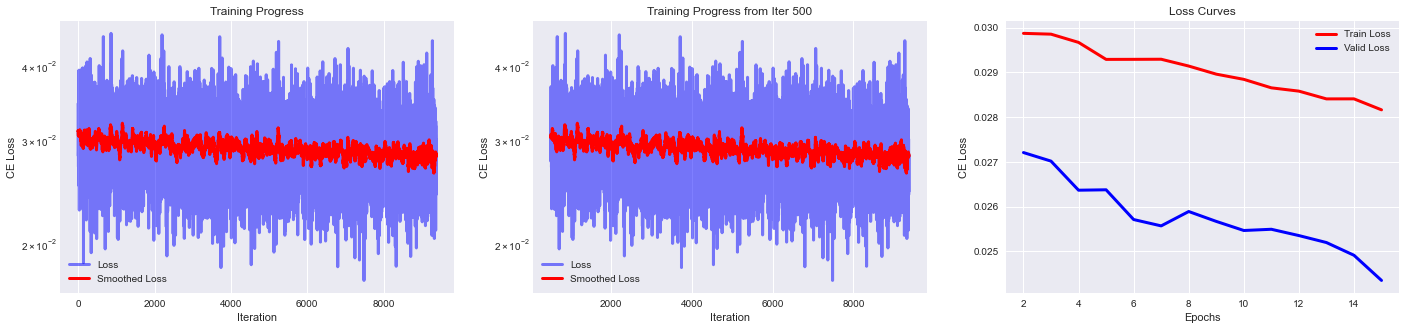

In [133]:
plt.style.use('seaborn')
fig, ax = plt.subplots(1,3)
fig.set_size_inches(24,5)

smooth_loss = smooth(loss_iters, 31)
ax[0].plot(loss_iters, c="blue", label="Loss", linewidth=3, alpha=0.5)
ax[0].plot(smooth_loss, c="red", label="Smoothed Loss", linewidth=3, alpha=1)
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("CE Loss")
ax[0].set_yscale("log")
ax[0].set_title("Training Progress")

smooth_loss = smooth(loss_iters, 31)
START = 500
N_ITERS = len(loss_iters)
ax[1].plot(np.arange(START, N_ITERS), loss_iters[START:], c="blue", label="Loss", linewidth=3, alpha=0.5)
ax[1].plot(np.arange(START, N_ITERS), smooth_loss[START:], c="red", label="Smoothed Loss", linewidth=3, alpha=1)
ax[1].legend(loc="best")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("CE Loss")
ax[1].set_yscale("log")
ax[1].set_title(f"Training Progress from Iter {START}")

epochs = np.arange(len(train_loss)) + 1
ax[2].plot(epochs[1:], train_loss[1:], c="red", label="Train Loss", linewidth=3)
ax[2].plot(epochs[1:], val_loss[1:], c="blue", label="Valid Loss", linewidth=3)
ax[2].legend(loc="best")
ax[2].set_xlabel("Epochs")
ax[2].set_ylabel("CE Loss")
ax[2].set_title("Loss Curves")


plt.show()

torch.Size([16, 1, 64, 64])


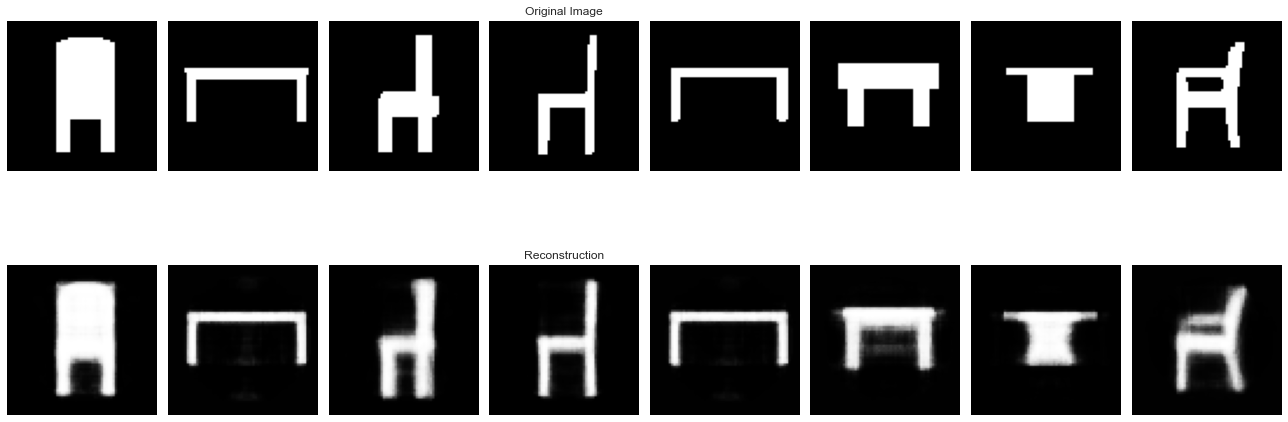

In [134]:
imgs = next(iter(valid_loader)) 
print(imgs[0].shape)
ae.eval()
with torch.no_grad():
    recons, _ = model(imgs[0].to(device))
    
fig, ax = plt.subplots(2, 8)
fig.set_size_inches(18, 8)
for i in range(8):
    #print(imgs[0][i].shape)
    ax[0, i].imshow(imgs[0][i].permute(1,2,0).numpy(), cmap="gray")
    ax[0, i].axis("off")
    ax[1, i].imshow(recons[i, 0].cpu().detach(), cmap="gray")
    ax[1, i].axis("off")

ax[0, 3].set_title("Original Image")
ax[1, 3].set_title("Reconstruction")
plt.tight_layout()
plt.show()